<a href="https://colab.research.google.com/github/ThanhTan1906/PH-N-T-CH-H-NH-VI-KH-CH-H-NG/blob/main/%5BCustomer_segmentation_kmeans%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

****Introduction****

Phân khúc khách hàng (Customer segmentation) là một kỹ thuật quan trọng trong phân tích dữ liệu, giúp doanh nghiệp hiểu được hành vi và sở thích của khách hàng. Bằng cách chia khách hàng thành các nhóm riêng biệt dựa trên các mô hình mua sắm, mức độ trung thành và các yếu tố nhân khẩu học khác, doanh nghiệp có thể điều chỉnh chiến lược marketing và cải thiện sự tương tác với khách hàng.

Trong phân tích này, chúng tôi áp dụng thuật toán K-Means Clustering để phân khúc khách hàng dựa trên các đặc trưng như độ tuổi, thu nhập hàng năm, số tiền chi tiêu, tần suất mua hàng và điểm trung thành. Để đánh giá chất lượng của việc phân cụm, chúng tôi sử dụng Silhouette Score, một chỉ số đo lường mức độ tách biệt giữa các cụm. Với giá trị Silhouette Score là 0.61, mô hình cho thấy chất lượng phân cụm ở mức tốt, mang lại những hiểu biết có giá trị cho các chiến lược marketing mục tiêu và duy trì khách hàng.

Báo cáo này trình bày kết quả của quá trình phân khúc, diễn giải đặc điểm của từng nhóm khách hàng và đề xuất các chiến lược marketing có thể thực hiện dựa trên những hiểu biết thu được từ quá trình phân cụm.


**Import Library**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

****EDA****

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/datasets/datasets.Project/Customer Purchasing Behaviors.csv")
data.head()

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             238 non-null    int64  
 1   age                 238 non-null    int64  
 2   annual_income       238 non-null    int64  
 3   purchase_amount     238 non-null    int64  
 4   loyalty_score       238 non-null    float64
 5   region              238 non-null    object 
 6   purchase_frequency  238 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 13.1+ KB


In [ ]:
data.describe()

,user_id,age,annual_income,purchase_amount,loyalty_score,purchase_frequency
count,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000
mean,119.500000,38.676471,57407.563025,425.630252,6.794118,19.798319
std,68.848868,9.351118,11403.875717,140.052062,1.899047,4.562884
min,1.000000,22.000000,30000.000000,150.000000,3.000000,10.000000
25%,60.250000,31.000000,50000.000000,320.000000,5.500000,17.000000
50%,119.500000,39.000000,59000.000000,440.000000,7.000000,20.000000
75%,178.750000,46.750000,66750.000000,527.500000,8.275000,23.000000
max,238.000000,55.000000,75000.000000,640.000000,9.500000,28.000000


In [ ]:
data.shape

(238, 7)

In [ ]:
data.isnull().sum()

,0
user_id,0
age,0
annual_income,0
purchase_amount,0
loyalty_score,0
region,0
purchase_frequency,0


**Histogram:**

Cho bạn biết:

* Khách hàng chi tiêu nhiều hay ít

* Phân bố dữ liệu (dồn về đâu)

**KDE (đường cong):**

* Giúp nhìn xu hướng tổng thể mượt hơn

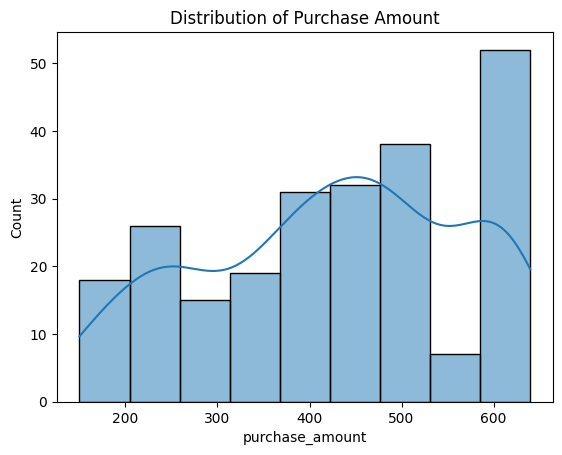

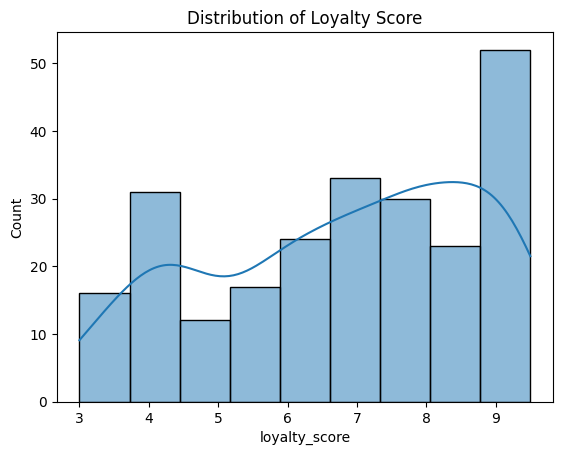

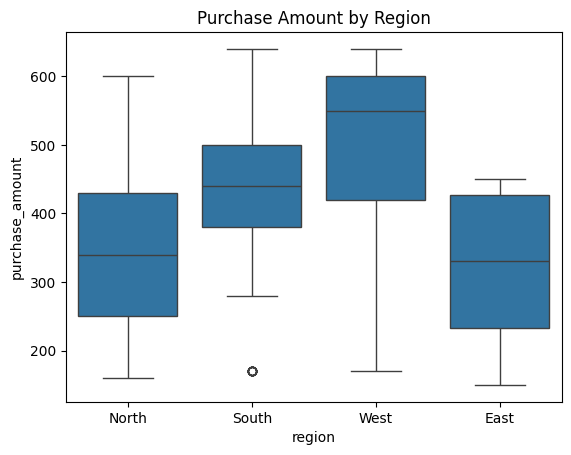

In [ ]:
sns.histplot(data['purchase_amount'], kde=True)
plt.title('Distribution of Purchase Amount')
plt.show()

sns.histplot(data['loyalty_score'], kde=True)
plt.title('Distribution of Loyalty Score')
plt.show()

sns.boxplot(x='region', y='purchase_amount', data=data.dropna())
plt.title('Purchase Amount by Region')
plt.show()

**Distribution of Purchase Amount**

Biểu đồ cho thấy mức chi tiêu của khách hàng chủ yếu nằm trong khoảng 300–600, với đỉnh tập trung khoảng 450–500, cho thấy phần lớn khách hàng có xu hướng chi tiêu trung bình đến cao. Phân bố hơi lệch về phía các giá trị lớn, đồng thời có một số ít khách hàng chi tiêu rất cao, có thể được xem là nhóm khách hàng giá trị cao.

**Distribution of Loyalty Score**

Biểu đồ cho thấy điểm trung thành của khách hàng chủ yếu nằm trong khoảng 6–9, với đỉnh tập trung khoảng 8–9. Điều này cho thấy phần lớn khách hàng có mức độ trung thành khá cao, trong khi số lượng khách có mức trung thành thấp là tương đối ít.

**Purchase Amount by Region**

Biểu đồ cho thấy khu vực West có mức chi tiêu cao nhất với median cao hơn các khu vực khác, tiếp theo là South, trong khi North và East có mức chi tiêu thấp hơn. Ngoài ra, South xuất hiện một số giá trị ngoại lai thấp, cho thấy có khách hàng chi tiêu rất thấp trong khu vực này.

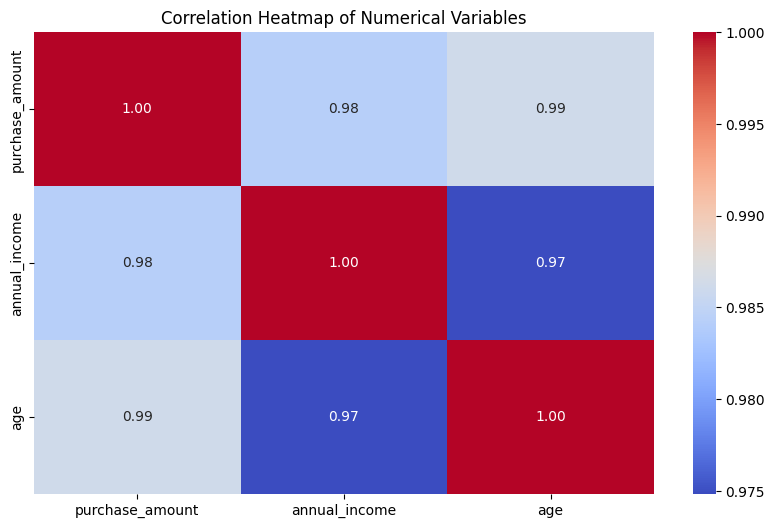

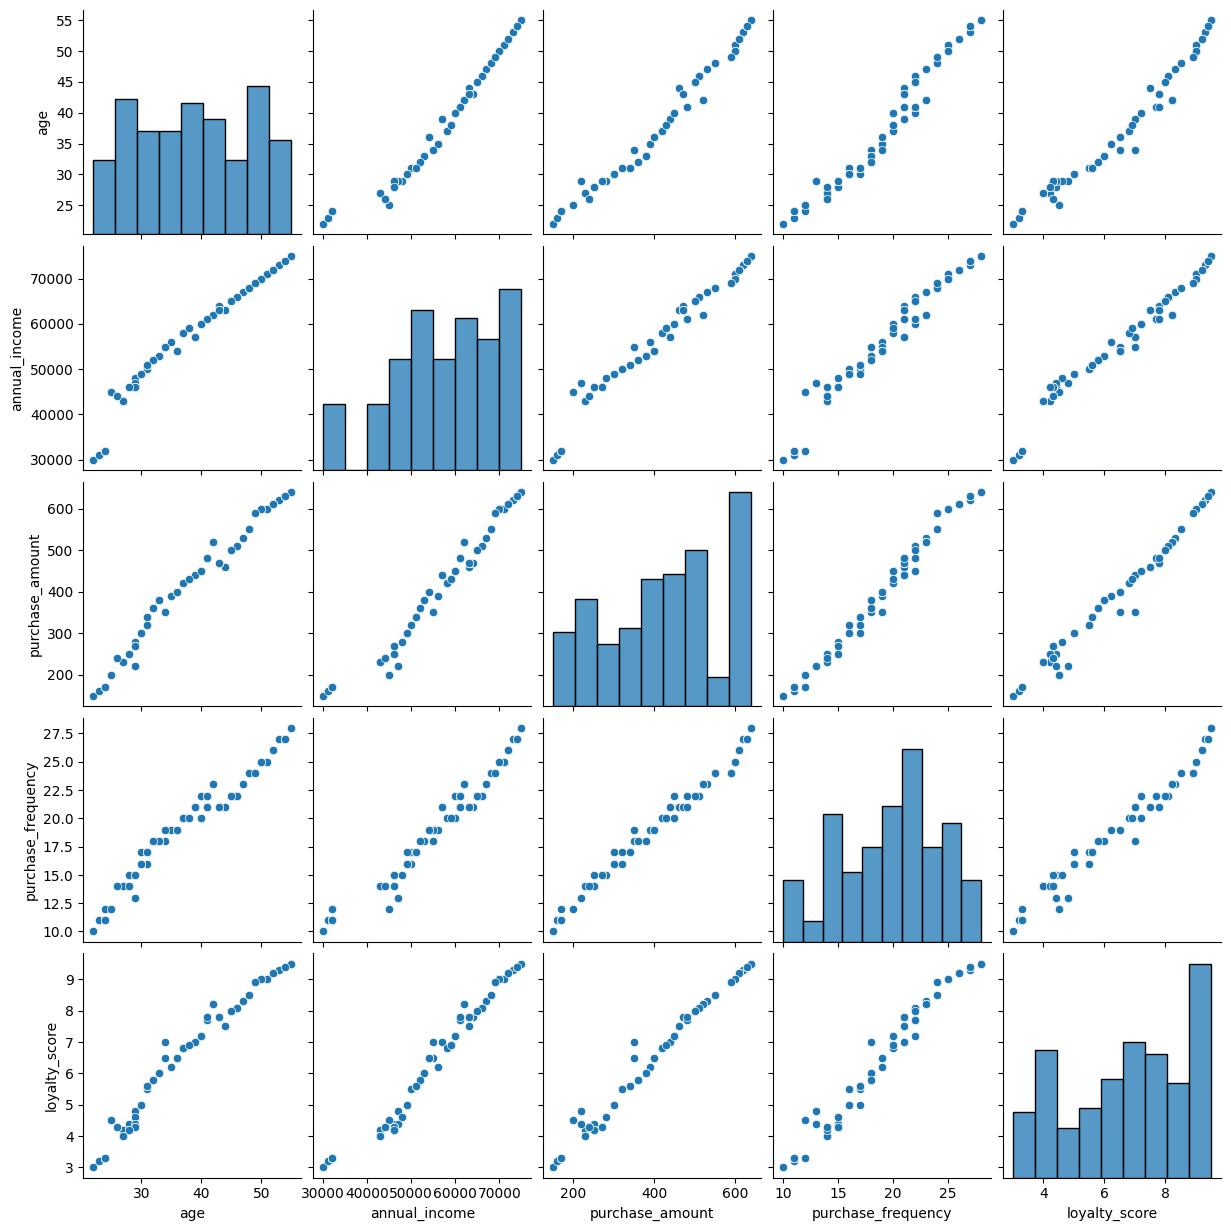

In [ ]:
corr_matrix = data[['purchase_amount', 'annual_income', 'age']].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

sns.pairplot(data[['age', 'annual_income', 'purchase_amount', 'purchase_frequency', 'loyalty_score']]) #Vẽ ma trận các biểu đồ để xem mối quan hệ giữa các biến
plt.show()

****Data Preprocessing****

In [ ]:
features = data[['purchase_amount', 'annual_income', 'loyalty_score', 'purchase_frequency']]
scaler = StandardScaler() # Tạo 1 bộ chuẩn hóa
scaled_data = scaler.fit_transform(features)
print(scaled_data[:5]) # 5 dòng đầu tiên của dữ liệu sau khi scale

[[-1.61444081 -1.09030579 -1.21058231 -1.71267859]
 [-0.54115334 -0.21156289  0.108642   -0.39494959]
 [ 0.53213412  0.66718001  0.63633173  0.48353641]
 [-1.9722033  -2.40842015 -2.0021169  -2.15192158]
 [-1.47133582 -0.91455721 -1.05227539 -1.49305709]]


****K-Means Clustering****

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=100) # n_clusters=4: chia khách hàng thành 4 nhóm (clusters), random_state=100: đảm bảo kết quả chạy lại vẫn giống nhau
data['Cluster'] = kmeans.fit_predict(scaled_data)
print(data.head())

   user_id  age  annual_income  purchase_amount  loyalty_score region  \
0        1   25          45000              200            4.5  North   
1        2   34          55000              350            7.0  South   
2        3   45          65000              500            8.0   West   
3        4   22          30000              150            3.0   East   
4        5   29          47000              220            4.8  North   

   purchase_frequency  Cluster  
0                  12        0  
1                  18        1  
2                  22        1  
3                  10        2  
4                  13        0  


**Elbow Method**

Tìm điểm mà việc tăng số cụm không còn cải thiện nhiều nữa

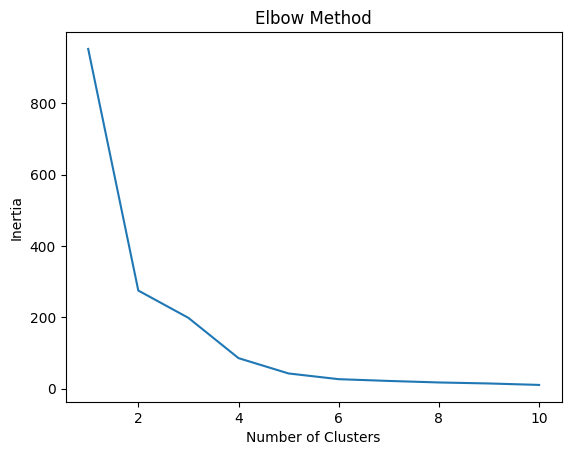

In [ ]:
inertia = [] # Lưu “độ lỗi” của từng mô hình
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=100)
    kmeans.fit(scaled_data) # Model sẽ phân cụm lại dữ liệu
    inertia.append(kmeans.inertia_) # Tổng khoảng cách từ các điểm đến tâm cụm
plt.plot(range(1, 11), inertia)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

**Nhận xét**

Biểu đồ Elbow cho thấy điểm gãy xuất hiện tại k = 3 hoặc k = 4, sau đó giá trị inertia giảm chậm lại. Do đó, lựa chọn k = 4 là hợp lý để phân cụm khách hàng.

**Silhouette Scrore**

* Các điểm trong cùng cụm có giống nhau không

* Các cụm có tách biệt rõ không


In [ ]:
silhouette_avg = silhouette_score(scaled_data, data['Cluster']) # So sánh Dữ liệu (scaled_data) và Nhãn cụm (Cluster)
print(f"Silhouette Score: {round(silhouette_avg, 2)}")

Silhouette Score: 0.58


**Nhận xét**

Giá trị Silhouette Score đạt khoảng 0.61, cho thấy mô hình phân cụm có chất lượng tốt và các cụm được phân tách tương đối rõ ràng.

**PCA: giảm số chiều dữ liệu**

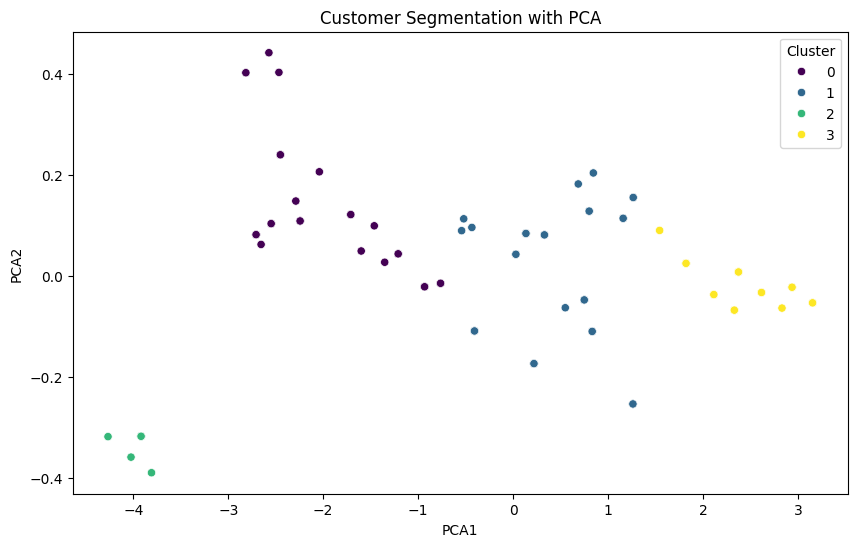

In [ ]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
data['PCA1'] = pca_data[:, 0]
data['PCA2'] = pca_data[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', palette='viridis', data=data)
plt.title('Customer Segmentation with PCA')
plt.show()

**Conclusion**

Cụm 0 (màu tím): Có khả năng đại diện cho nhóm khách hàng chi tiêu thấp hoặc mua hàng không thường xuyên. Doanh nghiệp nên áp dụng các chiến lược nhằm khuyến khích họ mua nhiều hơn và tăng mức độ trung thành.

Cụm 1 (màu xanh lá): Đây là nhóm khách hàng ở mức cân bằng, có tiềm năng phát triển. Việc cung cấp các ưu đãi cá nhân hóa hoặc chương trình khuyến khích có thể giúp tăng khả năng giữ chân và mức chi tiêu của họ.

Cụm 2 (màu xanh dương): Nhóm khách hàng có mức độ tương tác cao nhưng chi tiêu ở mức trung bình. Doanh nghiệp có thể điều chỉnh chiến lược marketing nhằm tăng tần suất mua hàng hoặc khuyến khích họ nâng cấp lên các sản phẩm cao cấp hơn.

Cụm 3 (màu vàng): Đây là nhóm khách hàng giá trị cao, có mức độ trung thành và chi tiêu lớn. Doanh nghiệp nên tập trung giữ chân nhóm này thông qua các dịch vụ cao cấp hoặc chương trình phần thưởng.

Cuối cùng, việc hiểu rõ hành vi của từng cụm khách hàng giúp doanh nghiệp xây dựng các chiến lược phù hợp nhằm nâng cao sự hài lòng, lòng trung thành và doanh thu tổng thể.